In [2]:
import sys
from pathlib import Path
import pandas as pd

# --- Setup Project Paths ---
# This ensures the notebook can find the 'src' directory
# Assumes the notebook is in 'notebooks/' and src is a sibling directory
# /home/mouneer_alrayes/graphage13-sorption/
#   ├── notebooks/
#   └── src/
#
# Get the project root directory
project_root = Path.cwd().parent 
# Add the 'src' directory to the Python path
sys.path.append(str(project_root / 'src'))

# Define the data directory path
DATA_DIR = project_root / 'data' / 'raw'

# --- Import Your Custom Ingestion Logic ---
# Now you can import from ingestion.py
from ingestion import ingest_sorption_data

# --- Run the Ingestion Pipeline ---
# This one function call processes all .xlsx files in your data directory
all_experiments = ingest_sorption_data(DATA_DIR)

# --- Explore the Ingested Data ---
# Separate successful from failed ingestions
successful_ingestions = []
failed_files = []

for data_package, meta in all_experiments:
    # Check if the parsing function returned an error
    if 'error' in meta:
        failed_files.append(meta.get('source_file', 'Unknown File') + f": {meta['error']}")
    else:
        # 1. Unpack the kinetic time-series DataFrame from the data package dictionary
        df = data_package['kinetic_data']
        
        # Add sample name to the dataframe for successful ingestions
        sample_name = meta.get('sample_name', meta.get('source_file', 'unknown_sample'))
        df['sample_name'] = sample_name
        successful_ingestions.append(df)

# --- Report on Ingestion Status ---
print(f"--- Ingestion Report ---")
print(f"Successfully parsed: {len(successful_ingestions)} file(s)")
print(f"Failed to parse:   {len(failed_files)} file(s)")

if failed_files:
    print("\n--- Failure Details ---")
    for reason in failed_files:
        print(f"- {reason}")

# --- Process and Display Successfully Ingested Data ---
if successful_ingestions:
    # Concatenate all individual dataframes into a single one
    master_df = pd.concat(successful_ingestions, ignore_index=True)
    
    print("\n--- Master DataFrame Head (Combined from all files) ---")
    display(master_df.head())
    
    print("\n--- Master DataFrame Info ---")
    master_df.info()
else:
    print("\nNo data was successfully ingested to create a master DataFrame.")

2026-07-02 01:03:03,773 - INFO - Starting ingestion from directory: /home/mouneer_alrayes/graphage13-sorption/data/raw
2026-07-02 01:03:03,775 - INFO - Processing file: 4M13 sample 3 17-05-24-0-90-0 0.002% stop 30min-12hr-2024-05-17 14-25-33.xlsx
2026-07-02 01:03:06,230 - INFO - Successfully parsed 2415 kinetic points and 31 isotherm points.
2026-07-02 01:03:06,232 - INFO - Processing file: GPA 0.002% 0-90-0 x 3.xlsx
2026-07-02 01:03:21,708 - INFO - Successfully parsed 14970 kinetic points and 50 isotherm points.
2026-07-02 01:03:21,710 - INFO - Processing file: GPA 80_ sample 3-0-90-0 0.002_ stop 30min-12hr-2024-06-07 13-43-07.xlsx
2026-07-02 01:03:26,168 - INFO - Successfully parsed 4517 kinetic points and 31 isotherm points.
2026-07-02 01:03:26,169 - INFO - Processing file: 0.25M13 sample 3-0-90-0 0.002% stop 30min-12hr-2024-05-31 15-04-20.xls
2026-07-02 01:03:27,414 - INFO - Successfully parsed 3391 kinetic points and 31 isotherm points.
2026-07-02 01:03:27,415 - INFO - Processing 

--- Ingestion Report ---
Successfully parsed: 5 file(s)
Failed to parse:   0 file(s)

--- Master DataFrame Head (Combined from all files) ---


,time_minutes_,mass_mg_,delta_mass_,dm_dt_minute_,target_incubator_temp_celsius_,measured_incubator_temp_celsius_,target_preheater_temp_celsius_,measured_preheater_temp_celsius_,sorption_temp_celsius_,target_partial_pressure_solvent_a_,...,unnamed_84,target_chiller_temp_celsius_,measured_chiller_temp_celsius_,measured_chiller_internal_temp_celsius_,chiller_state,gas_concentration_sensor_a_ppm_,gas_concentration_sensor_b_ppm_,sample_name,target_p_p0,dm_
0,0.00,3.7727,75.454,-394.5271,25,24.8,0,0,24.9,0.0,...,0,-10,0,0,Off,0,0,4M13 sample 3 17:05:24:0:90:0 0.002% stop 30mi...,NaN,NaN
1,1.00,3.7041,74.082,-0.4714,25,25.0,0,0,24.9,0.0,...,0,-10,0,0,Off,0,0,4M13 sample 3 17:05:24:0:90:0 0.002% stop 30mi...,NaN,NaN
2,2.01,3.6604,73.208,379.7382,25,25.0,0,0,25.0,0.0,...,0,-10,0,0,Off,0,0,4M13 sample 3 17:05:24:0:90:0 0.002% stop 30mi...,NaN,NaN
3,3.01,3.6357,72.714,709.7727,25,25.0,0,0,25.0,0.0,...,0,-10,0,0,Off,0,0,4M13 sample 3 17:05:24:0:90:0 0.002% stop 30mi...,NaN,NaN
4,4.01,3.6196,72.392,110.2624,25,25.0,0,0,25.0,0.0,...,0,-10,0,0,Off,0,0,4M13 sample 3 17:05:24:0:90:0 0.002% stop 30mi...,NaN,NaN



--- Master DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30076 entries, 0 to 30075
Data columns (total 94 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   time_minutes_                            30076 non-null  float64
 1   mass_mg_                                 30076 non-null  float64
 2   delta_mass_                              30076 non-null  float64
 3   dm_dt_minute_                            30076 non-null  float64
 4   target_incubator_temp_celsius_           30076 non-null  int64  
 5   measured_incubator_temp_celsius_         30076 non-null  float64
 6   target_preheater_temp_celsius_           30076 non-null  int64  
 7   measured_preheater_temp_celsius_         30076 non-null  int64  
 8   sorption_temp_celsius_                   30076 non-null  float64
 9   target_partial_pressure_solvent_a_       15106 non-null  float64
 10  measured_partia

In [3]:
# --- Step 1.5: Isolate Kinetic Modeling Essentials ---

# Define the precise column parameters needed for mass-uptake calculations
essential_columns = [
    'sample_name', 
    'time_minutes_', 
    'mass_mg_', 
    'delta_mass_', 
    'dm_dt_minute_', 
    'sorption_temp_celsius_',
    'measured_partial_pressure_solvent_a_',
    'target_partial_pressure_solvent_a_'  # This tracks your relative humidity / P/P0 steps
]

# Extract only the essential features into a pristine modeling dataframe
kinetic_df = master_df[essential_columns].copy()

# Rename the primary humidity column to something standard for easier math scripting
kinetic_df.rename(columns={'measured_partial_pressure_solvent_a_': 'measured_rh'}, inplace=True)

print("--- Pristine Kinetics DataFrame Verified ---")
kinetic_df.info()

--- Pristine Kinetics DataFrame Verified ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30076 entries, 0 to 30075
Data columns (total 8 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   sample_name                         30076 non-null  object 
 1   time_minutes_                       30076 non-null  float64
 2   mass_mg_                            30076 non-null  float64
 3   delta_mass_                         30076 non-null  float64
 4   dm_dt_minute_                       30076 non-null  float64
 5   sorption_temp_celsius_              30076 non-null  float64
 6   measured_rh                         30076 non-null  float64
 7   target_partial_pressure_solvent_a_  15106 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.8+ MB


In [4]:
import numpy as np
import pandas as pd

def segment_humidity_stages_by_target(df: pd.DataFrame, target_col: str = 'target_partial_pressure_solvent_a_') -> pd.DataFrame:
    """
    Segments a continuous DVS time-series into discrete stages, 
    processing each sample independently so stage_ids reset to 0.
    """
    working_df = df.copy()
    processed_samples = []
    
    # Process every sample completely independently
    for sample_name, group in working_df.groupby('sample_name'):
        group = group.copy()
        
        # 1. Step change triggers
        group['step_changed'] = group[target_col].diff().fillna(0) != 0
        
        # 2. Stage IDs (Now resets to 0 for every new sample!)
        group['stage_id'] = group['step_changed'].cumsum().astype(int)
        
        # 3. Determine Sorption vs Desorption
        stage_targets = group.groupby('stage_id')[target_col].first()
        stage_directions = {}
        
        previous_target = stage_targets.iloc[0]
        stage_directions[stage_targets.index[0]] = 'sorption' 
        
        for stage, current_target in stage_targets.iloc[1:].items():
            if current_target >= previous_target:
                stage_directions[stage] = 'sorption'
            else:
                stage_directions[stage] = 'desorption'
            previous_target = current_target
            
        group['direction'] = group['stage_id'].map(stage_directions)
        group.drop(columns=['step_changed'], inplace=True)
        
        processed_samples.append(group)
        
    # Stitch the properly isolated samples back together
    return pd.concat(processed_samples, ignore_index=True)

# Run the fixed segmentation
segmented_df = segment_humidity_stages_by_target(kinetic_df)

# --- Run the Segmentation ---
segmented_df = segment_humidity_stages_by_target(kinetic_df)

print("--- Segmented DataFrame Preview ---")
display(segmented_df[['sample_name', 'time_minutes_', 'measured_rh', 'target_partial_pressure_solvent_a_', 'stage_id', 'direction']].head(20))

--- Segmented DataFrame Preview ---


,sample_name,time_minutes_,measured_rh,target_partial_pressure_solvent_a_,stage_id,direction
0,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,0.00,0.01,0.0,0,sorption
1,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,1.00,0.01,0.0,0,sorption
2,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,2.01,0.01,0.0,0,sorption
3,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,3.01,0.01,0.0,0,sorption
4,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,4.01,0.01,0.0,0,sorption
5,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,5.01,0.01,0.0,0,sorption
6,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,6.02,0.01,0.0,0,sorption
7,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,7.03,0.01,0.0,0,sorption
8,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,8.03,0.01,0.0,0,sorption
9,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,9.03,0.01,0.0,0,sorption


In [12]:
# --- Step 3: Define Dry-Mass Baseline & Compute % Mass Change ---

# 1. Isolate Stage 0 (the initial 0% RH drying phase)
# 2. Group by sample name and grab the very last mass reading (.last()) for each sample
m0_series = segmented_df[segmented_df['stage_id'] == 0].groupby('sample_name')['mass_mg_'].last()

# 3. Map these absolute dry-mass values back to every row in the main dataframe
segmented_df['reference_mass_m0'] = segmented_df['sample_name'].map(m0_series)

# 4. Calculate the % mass change for the entire timeline
segmented_df['mass_change_pct'] = ((segmented_df['mass_mg_'] - segmented_df['reference_mass_m0']) / segmented_df['reference_mass_m0']) * 100

# Print a clean preview to verify the math
print("✅ Baseline mapping and % mass change calculation complete.")
display(segmented_df[['sample_name', 'time_minutes_', 'stage_id', 'target_partial_pressure_solvent_a_', 'mass_mg_', 'reference_mass_m0', 'mass_change_pct']].head())

✅ Baseline mapping and % mass change calculation complete.


,sample_name,time_minutes_,stage_id,target_partial_pressure_solvent_a_,mass_mg_,reference_mass_m0,mass_change_pct
0,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,0.00,0,0.0,2.2777,2.1261,7.130427
1,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,1.00,0,0.0,2.2496,2.1261,5.808758
2,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,2.01,0,0.0,2.2262,2.1261,4.708151
3,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,3.01,0,0.0,2.2113,2.1261,4.007337
4,0.25M13 sample 3:0:90:0 0.002% stop 30min:12hr...,4.01,0,0.0,2.2011,2.1261,3.527586


In [15]:
# --- Step 4: Robust Equilibrium Capacity & Timeout Validation ---

validation_results = []
timeout_flags = []

for raw_name, group in segmented_df.groupby('sample_name'):
    name_lower = raw_name.lower()
    
    # 1. Identify the peak sorption stage (where the maximum mass change occurs)
    peak_stage_id = group.loc[group['mass_change_pct'].idxmax(), 'stage_id']
    peak_stage = group[group['stage_id'] == peak_stage_id]
    
    # 2. Calculate the stage duration to check for 12-hour cap timeouts
    stage_duration = peak_stage['time_minutes_'].iloc[-1] - peak_stage['time_minutes_'].iloc[0]
    is_timeout = stage_duration >= 700.0  # ~12 hours (720 mins) timeout window
    
    # 3. Robust Capacity Definition: Mean of the last 30 rows/minutes of that stable window
    equilibrium_capacity = peak_stage['mass_change_pct'].tail(30).mean()
    
    # Grab the baseline mass
    m0 = group['reference_mass_m0'].iloc[0]
    
    # 4. Apply Corrected Physical Identity Mappings
    clean_name = "Unknown"
    target_val = "N/A"
    
    if 'baked' in name_lower:
        clean_name = 'Baked GPA'
        target_val = '70.5 %'
    elif '80' in name_lower:
        clean_name = 'GPA 80%'
        target_val = '72.4 %'
    elif '4m13' in name_lower:
        clean_name = 'GPA 1:4'      # Corrected
        target_val = '54.7 %'       # Corrected
    elif '0.25m13' in name_lower:
        clean_name = 'GPA 4:1'      # Corrected
        target_val = '54.9 %'       # Corrected
    elif 'gpa' in name_lower:
        clean_name = 'GPA (Standard)'
        target_val = '67.9 %'
        
    if is_timeout:
        timeout_flags.append(f"{clean_name} (Stage {peak_stage_id}, Duration: {stage_duration:.1f} mins)")
        
    validation_results.append({
        'Assigned Sample': clean_name,
        'Dry Mass (m0)': f"{m0:.4f} mg",
        'Equilibrium Capacity': f"{equilibrium_capacity:.2f} %",
        'Target Benchmark': target_val,
        '12h Time Cap Hit?': " YES (Flagged)" if is_timeout else "No"
    })

# Render and display the finalized table
final_table_df = pd.DataFrame(validation_results).sort_values('Assigned Sample')
display(final_table_df)

print("\n🚨 --- Project Playbook Mandatory Flags ---")
print(f"Stages that hit the 12h time cap limit: {timeout_flags}")

,Assigned Sample,Dry Mass (m0),Equilibrium Capacity,Target Benchmark,12h Time Cap Hit?
4,Baked GPA,1.4585 mg,71.11 %,70.5 %,YES (Flagged)
2,GPA (Standard),2.5321 mg,0.02 %,67.9 %,YES (Flagged)
1,GPA 1:4,3.5026 mg,55.48 %,54.7 %,No
0,GPA 4:1,2.1261 mg,53.03 %,54.9 %,YES (Flagged)
3,GPA 80%,1.6996 mg,79.40 %,72.4 %,YES (Flagged)



🚨 --- Project Playbook Mandatory Flags ---
Stages that hit the 12h time cap limit: ['GPA 4:1 (Stage 9, Duration: 719.5 mins)', 'GPA (Standard) (Stage 0, Duration: 14996.0 mins)', 'GPA 80% (Stage 9, Duration: 719.4 mins)', 'Baked GPA (Stage 9, Duration: 718.5 mins)']


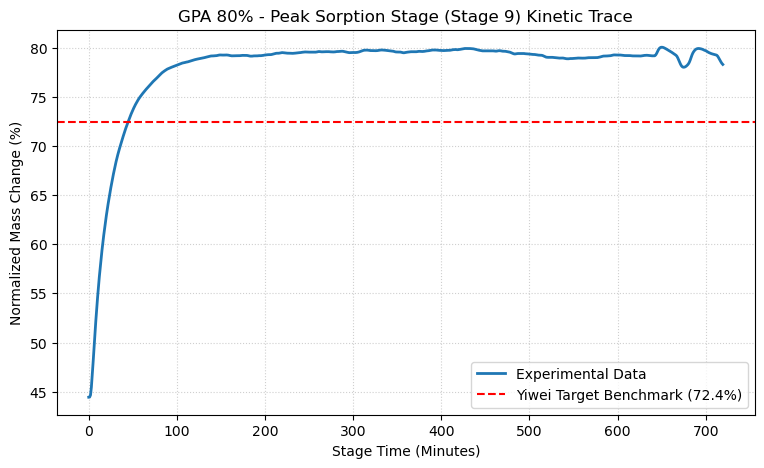

 Stage Total Duration: 719.4 minutes (~12.0 hours)
 Transient Peak Capacity: 80.05%
 Final Window Mass Value: 78.29%


In [11]:
import matplotlib.pyplot as plt

# 1. Isolate the GPA 80% sample
gpa_80 = segmented_df[segmented_df['sample_name'].str.contains('80', case=False)]

# 2. Isolate its peak sorption stage (usually the maximum stage_id or where target RH == 90%)
# Let's find the stage where it hits the absolute maximum mass_change_pct
peak_stage_id = gpa_80.loc[gpa_80['mass_change_pct'].idxmax(), 'stage_id']
peak_stage = gpa_80[gpa_80['stage_id'] == peak_stage_id].copy()

# Reset the stage clock to t=0 for clear kinetic viewing
peak_stage['stage_time'] = peak_stage['time_minutes_'] - peak_stage['time_minutes_'].iloc[0]

# 3. Plot the trace
plt.figure(figsize=(9, 5))
plt.plot(peak_stage['stage_time'], peak_stage['mass_change_pct'], color='#1f77b4', lw=2, label='Experimental Data')
plt.axhline(y=72.4, color='r', linestyle='--', label='Yiwei Target Benchmark (72.4%)')

# Annotate metrics
max_val = peak_stage['mass_change_pct'].max()
end_val = peak_stage['mass_change_pct'].iloc[-1]
total_duration = peak_stage['stage_time'].iloc[-1]

plt.title(f"GPA 80% - Peak Sorption Stage (Stage {peak_stage_id}) Kinetic Trace")
plt.xlabel("Stage Time (Minutes)")
plt.ylabel("Normalized Mass Change (%)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print(f" Stage Total Duration: {total_duration:.1f} minutes (~{total_duration/60:.1f} hours)")
print(f" Transient Peak Capacity: {max_val:.2f}%")
print(f" Final Window Mass Value: {end_val:.2f}%")